# Phase 3 — Image Preprocessing

## Image Processing Based Smart Supermarket Product Identification System

### EC9570 – Digital Image Processing
### University of Jaffna – Faculty of Engineering

---

### Objective

This phase implements and verifies image preprocessing techniques required
for the supermarket product identification system.

The preprocessing pipeline focuses on:

- Image loading and validation
- Image property analysis
- Image resizing
- Appropriate noise removal
- Visual comparison before and after preprocessing
- Verification that product information and bounding-box regions are preserved

The preprocessing operations are designed to prepare supermarket product
images for the subsequent object detection and classification stage while
preserving important product appearance and spatial information.

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3
Pandas version: 2.2.3


In [12]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Drive mounted:", drive_root.exists())

if drive_root.exists():
    print("\nMyDrive contents:")
    for item in list(drive_root.iterdir())[:50]:
        print(item)

Drive mounted: True

MyDrive contents:
/content/drive/MyDrive/Getting started.pdf
/content/drive/MyDrive/200182003915-pp.jpg
/content/drive/MyDrive/200182003915-PP.jpg
/content/drive/MyDrive/200182003915-NICF.jpg
/content/drive/MyDrive/200182003915-NICR.jpg
/content/drive/MyDrive/GDToT
/content/drive/MyDrive/IMG-20210405-WA0001.jpg
/content/drive/MyDrive/Loved one
/content/drive/MyDrive/A8FE4B15-0972-4C1D-B784-1FE0314950D9.jpeg
/content/drive/MyDrive/2C424FEA-687E-4490-AEBC-3698AB96B575.png
/content/drive/MyDrive/IMG_4494.jpeg
/content/drive/MyDrive/Google AI Studio
/content/drive/MyDrive/varnaja.pdf
/content/drive/MyDrive/Varnaja U..pdf
/content/drive/MyDrive/Equipment Request Management System .gdoc
/content/drive/MyDrive/Saved from Chrome
/content/drive/MyDrive/developer_erms.docx
/content/drive/MyDrive/RADocument.docx
/content/drive/MyDrive/Documentation_QA.docx
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/EWaste_Project
/content/drive/MyDrive/cv_project
/content/d

In [14]:
PROJECT_DATASET_DIR = Path(
    "/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset"
)

TRAIN_IMAGES_DIR = PROJECT_DATASET_DIR / "train" / "images"
TRAIN_LABELS_DIR = PROJECT_DATASET_DIR / "train" / "labels"

VAL_IMAGES_DIR = PROJECT_DATASET_DIR / "val" / "images"
VAL_LABELS_DIR = PROJECT_DATASET_DIR / "val" / "labels"

TEST_IMAGES_DIR = PROJECT_DATASET_DIR / "test" / "images"
TEST_LABELS_DIR = PROJECT_DATASET_DIR / "test" / "labels"

print("========== DATASET PATHS ==========")

for name, path in {
    "Train images": TRAIN_IMAGES_DIR,
    "Train labels": TRAIN_LABELS_DIR,
    "Validation images": VAL_IMAGES_DIR,
    "Validation labels": VAL_LABELS_DIR,
    "Test images": TEST_IMAGES_DIR,
    "Test labels": TEST_LABELS_DIR
}.items():

    print(f"{name:25s}: {path}")
    print(f"{'Exists':25s}: {path.exists()}")
    print()

========== DATASET PATHS ==========
Train images             : /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/train/images
Exists                   : True

Train labels             : /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/train/labels
Exists                   : True

Validation images        : /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/val/images
Exists                   : True

Validation labels        : /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/val/labels
Exists                   : True

Test images              : /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/test/images
Exists                   : True

Test labels              : /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/test/labels
Exists                   : True



In [15]:
print("========== IMAGE COUNTS ==========")

for split, image_dir in {
    "TRAIN": TRAIN_IMAGES_DIR,
    "VAL": VAL_IMAGES_DIR,
    "TEST": TEST_IMAGES_DIR
}.items():

    images = list(image_dir.glob("*.jpg"))

    print(f"{split:5s}: {len(images)} images")

========== IMAGE COUNTS ==========
TRAIN: 5000 images
VAL  : 1000 images
TEST : 1000 images


In [16]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset"
)

TRAIN_IMAGES_DIR = PROJECT_ROOT / "train" / "images"
TRAIN_LABELS_DIR = PROJECT_ROOT / "train" / "labels"

VAL_IMAGES_DIR = PROJECT_ROOT / "val" / "images"
VAL_LABELS_DIR = PROJECT_ROOT / "val" / "labels"

TEST_IMAGES_DIR = PROJECT_ROOT / "test" / "images"
TEST_LABELS_DIR = PROJECT_ROOT / "test" / "labels"

print("Project dataset:", PROJECT_ROOT)

print("\nTrain images:", TRAIN_IMAGES_DIR)
print("Validation images:", VAL_IMAGES_DIR)
print("Test images:", TEST_IMAGES_DIR)

Project dataset: /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset

Train images: /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/train/images
Validation images: /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/val/images
Test images: /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/test/images


## 4. Dataset Structure Verification

Before preprocessing, the prepared dataset is checked to ensure
that all image directories exist and contain the expected images.

This prevents preprocessing from being performed on an incomplete
dataset.

In [17]:
def count_files(directory, extension):
    return len(list(directory.glob(extension)))


print("========== DATASET STRUCTURE ==========")

for split, image_dir, label_dir in [
    ("TRAIN", TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR),
    ("VAL", VAL_IMAGES_DIR, VAL_LABELS_DIR),
    ("TEST", TEST_IMAGES_DIR, TEST_LABELS_DIR)
]:

    print(f"\n{split}")
    print("Images :", count_files(image_dir, "*.jpg"))
    print("Labels :", count_files(label_dir, "*.txt"))

========== DATASET STRUCTURE ==========

TRAIN
Images : 5000
Labels : 5000

VAL
Images : 1000
Labels : 1000

TEST
Images : 1000
Labels : 1000


## 5. Project Class Definition

The original RPC dataset contains 200 fine-grained product categories.

For this project, these categories were grouped into 17 meaningful
supercategories during Phase 2.

The preprocessing stage does not change these class labels.

In [18]:
CLASS_NAMES = [
    "alcohol",
    "candy",
    "canned_food",
    "chocolate",
    "dessert",
    "dried_food",
    "dried_fruit",
    "drink",
    "gum",
    "instant_drink",
    "instant_noodles",
    "milk",
    "personal_hygiene",
    "puffed_food",
    "seasoner",
    "stationery",
    "tissue"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of project classes:", NUM_CLASSES)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i:2d} -> {name}")

Number of project classes: 17
 0 -> alcohol
 1 -> candy
 2 -> canned_food
 3 -> chocolate
 4 -> dessert
 5 -> dried_food
 6 -> dried_fruit
 7 -> drink
 8 -> gum
 9 -> instant_drink
10 -> instant_noodles
11 -> milk
12 -> personal_hygiene
13 -> puffed_food
14 -> seasoner
15 -> stationery
16 -> tissue


## 6. Sample Image Inspection

A small number of images are loaded from each split to understand
their original dimensions and visual characteristics.

This is important because supermarket checkout images contain
multiple products, different product sizes, packaging colours and
different levels of visual complexity.

In [19]:
def get_sample_images(image_dir, n=5):
    files = sorted(image_dir.glob("*.jpg"))
    return files[:n]


train_samples = get_sample_images(TRAIN_IMAGES_DIR, 5)
val_samples = get_sample_images(VAL_IMAGES_DIR, 5)
test_samples = get_sample_images(TEST_IMAGES_DIR, 5)

print("Train samples:", len(train_samples))
print("Validation samples:", len(val_samples))
print("Test samples:", len(test_samples))

Train samples: 5
Validation samples: 5
Test samples: 5


## 7. Image Dimension Analysis

Image dimensions are examined before preprocessing.

The YOLO26s model will use a consistent input size during training
and inference. Therefore, the original image dimensions must be
understood before selecting a resizing strategy.

In [21]:
# Analyze only a representative sample
SAMPLE_SIZE = 200

train_image_files = sorted(
    TRAIN_IMAGES_DIR.glob("*.jpg")
)[:SAMPLE_SIZE]

dimension_records = []

for path in train_image_files:

    image = cv2.imread(str(path))

    if image is None:
        continue

    height, width = image.shape[:2]

    dimension_records.append({
        "filename": path.name,
        "width": width,
        "height": height,
        "channels": image.shape[2] if len(image.shape) == 3 else 1
    })

dimension_df = pd.DataFrame(dimension_records)

print("========== IMAGE DIMENSION ANALYSIS ==========")
print("Images analyzed:", len(dimension_df))

display(dimension_df.head())

========== IMAGE DIMENSION ANALYSIS ==========
Images analyzed: 200


,filename,width,height,channels
0,038900004095_camera0-15.jpg,2592,1944,3
1,038900004095_camera0-17.jpg,2592,1944,3
2,038900004095_camera0-29.jpg,2592,1944,3
3,038900004095_camera0-37.jpg,2592,1944,3
4,038900004095_camera1-11.jpg,2592,1944,3


In [22]:
print("========== DIMENSION SUMMARY ==========")

print("Width:")
print(dimension_df["width"].describe())

print("\nHeight:")
print(dimension_df["height"].describe())

print("\nChannels:")
print(dimension_df["channels"].value_counts())

========== DIMENSION SUMMARY ==========
Width:
count     200.0
mean     2592.0
std         0.0
min      2592.0
25%      2592.0
50%      2592.0
75%      2592.0
max      2592.0
Name: width, dtype: float64

Height:
count     200.0
mean     1944.0
std         0.0
min      1944.0
25%      1944.0
50%      1944.0
75%      1944.0
max      1944.0
Name: height, dtype: float64

Channels:
channels
3    200
Name: count, dtype: int64


## 8. Original Image Visualization

Representative images are visualized before preprocessing.

The purpose is to identify:

- Product colour information
- Product shape
- Packaging details
- Lighting variation
- Image quality
- Multiple-product layouts
- Potential noise or blur

These characteristics are important for retail product detection.

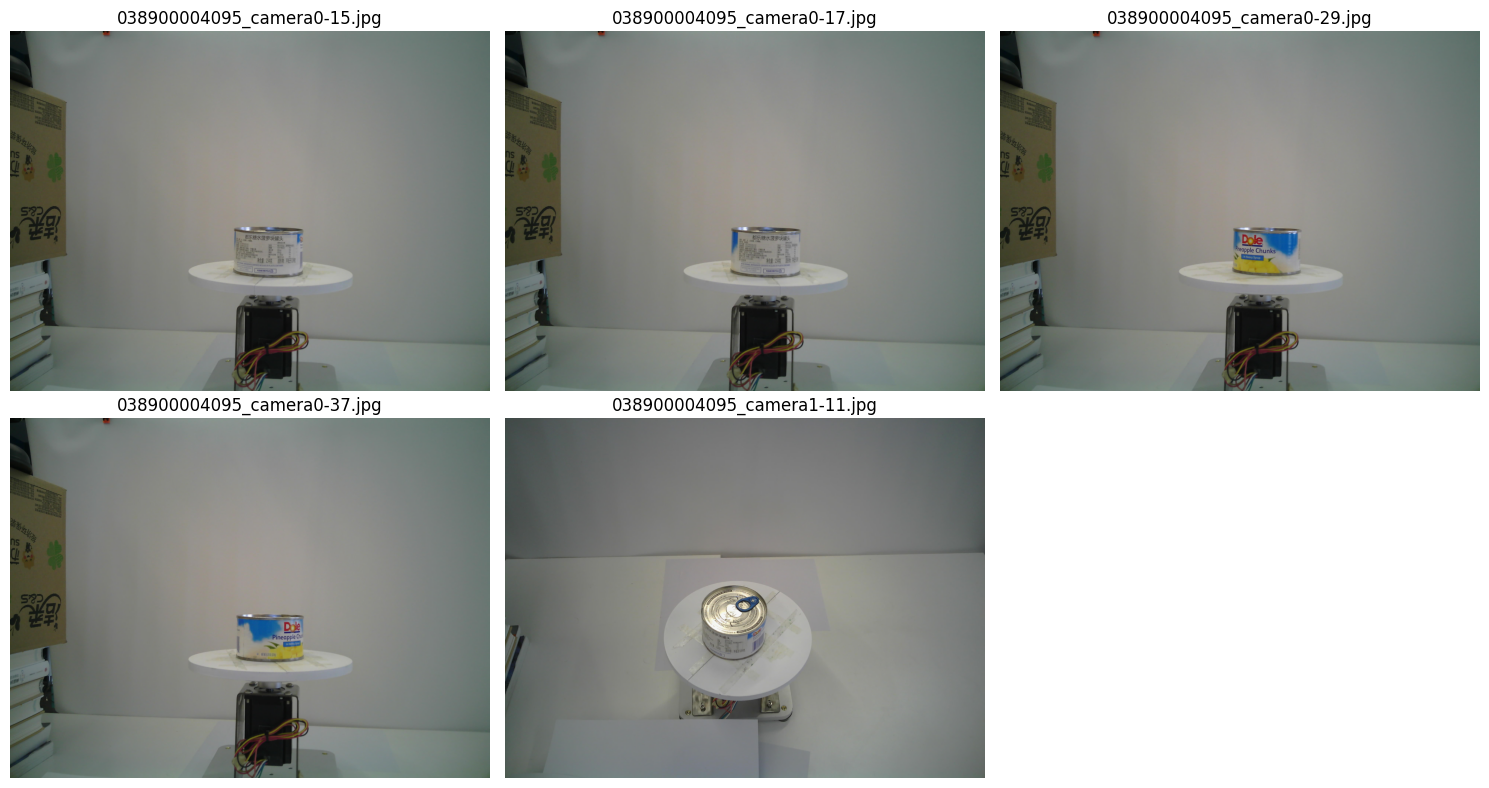

In [23]:
sample_paths = train_samples[:5]

plt.figure(figsize=(15, 8))

for i, path in enumerate(sample_paths):
    image = cv2.imread(str(path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(image_rgb)
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. OpenCV Preprocessing Functions

The preprocessing pipeline is designed around the requirements of
retail product detection.

The following operations are implemented:

1. Image loading
2. Colour conversion from BGR to RGB for visualization
3. Resizing while preserving aspect ratio
4. Padding to a fixed target size
5. Pixel normalization

The preprocessing does not modify the product class labels.

Bounding boxes remain valid because the geometric transformation
is explicitly controlled.

### Why these operations?

#### Resizing
A consistent input resolution is required by the object detection
model.

#### Aspect-ratio preservation
Directly stretching an image can distort product shapes. Therefore,
aspect-ratio-preserving resizing is preferred.

#### Padding
Padding allows images with different aspect ratios to fit a fixed
input size without geometric distortion.

#### Normalization
Pixel values can be converted from the standard 0-255 range to
0-1 when required by the preprocessing pipeline.

### Operations deliberately excluded from the final pipeline

- Grayscale conversion
- Edge detection
- Aggressive sharpening
- Heavy Gaussian blurring

These operations may remove colour, texture or packaging information
that can be useful for retail product recognition.

In [24]:
TARGET_SIZE = 640


def letterbox_image(
    image,
    target_size=640,
    pad_value=114
):
    """
    Resize an image while preserving aspect ratio,
    then pad it to target_size x target_size.
    """

    original_height, original_width = image.shape[:2]

    scale = min(
        target_size / original_width,
        target_size / original_height
    )

    new_width = int(round(original_width * scale))
    new_height = int(round(original_height * scale))

    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=cv2.INTER_LINEAR
    )

    canvas = np.full(
        (target_size, target_size, 3),
        pad_value,
        dtype=np.uint8
    )

    pad_x = (target_size - new_width) // 2
    pad_y = (target_size - new_height) // 2

    canvas[
        pad_y:pad_y + new_height,
        pad_x:pad_x + new_width
    ] = resized

    return canvas, scale, pad_x, pad_y

## 10. Preprocessing Function Verification

The preprocessing function is tested using representative RPC images.

The output must:

- Have the expected dimensions
- Remain a valid colour image
- Preserve the overall product appearance
- Avoid severe geometric distortion

In [25]:
sample_path = train_samples[0]

original = cv2.imread(str(sample_path))

processed, scale, pad_x, pad_y = letterbox_image(
    original,
    target_size=TARGET_SIZE
)

print("Original shape :", original.shape)
print("Processed shape:", processed.shape)
print("Scale factor   :", scale)
print("Padding X      :", pad_x)
print("Padding Y      :", pad_y)

Original shape : (1944, 2592, 3)
Processed shape: (640, 640, 3)
Scale factor   : 0.24691358024691357
Padding X      : 0
Padding Y      : 80


## 11. Original vs Preprocessed Image

The original image and the aspect-ratio-preserving preprocessed
image are compared visually.

This verifies that preprocessing does not introduce severe
distortion or remove important product information.

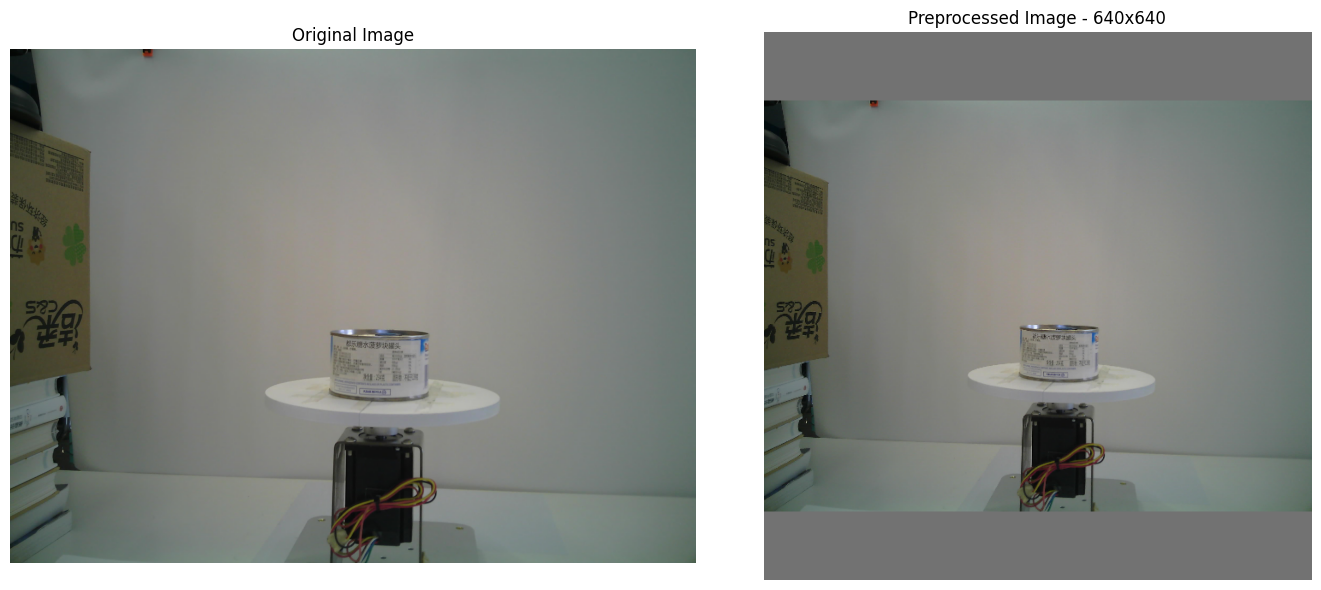

In [26]:
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_rgb)
plt.title("Preprocessed Image - 640x640")
plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Pixel Normalization Verification

For model input, image pixels can be represented as floating-point
values in the range [0, 1].

The original OpenCV image remains in uint8 format for efficient
storage and processing. Normalization is applied only when preparing
the image for model input.

In [27]:
normalized = processed.astype(np.float32) / 255.0

print("Original dtype :", processed.dtype)
print("Normalized dtype:", normalized.dtype)

print("Original range:",
      processed.min(),
      "to",
      processed.max())

print("Normalized range:",
      normalized.min(),
      "to",
      normalized.max())

Original dtype : uint8
Normalized dtype: float32
Original range: 0 to 255
Normalized range: 0.0 to 1.0


## 13. Evaluation of Grayscale Conversion

Grayscale conversion is demonstrated as an experimental operation,
but it is not selected as the final preprocessing method.

Retail products frequently differ in packaging colour and visual
appearance. Removing colour information may reduce useful features
for distinguishing products.

Therefore, the final detection pipeline retains three-channel
colour images.

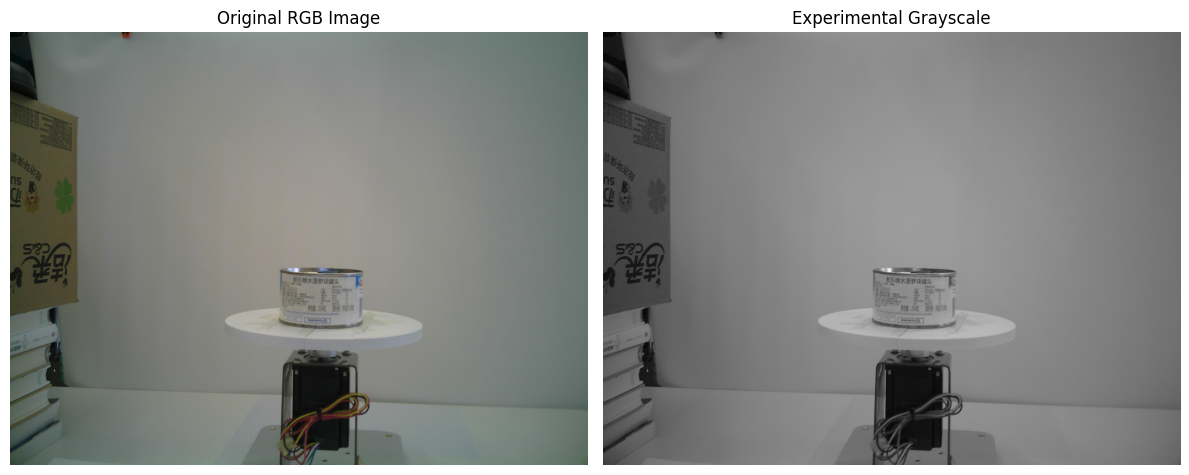

Original channels : 3
Grayscale channels: 1


In [28]:
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Experimental Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original channels :", original.shape[2])
print("Grayscale channels:", 1)

## 14. Noise Reduction Experiment

A mild Gaussian blur is evaluated as an optional preprocessing
operation.

Heavy smoothing is avoided because small product details and
packaging text can contribute to recognition.

The experiment is therefore used to determine whether filtering
should be included in the final pipeline.

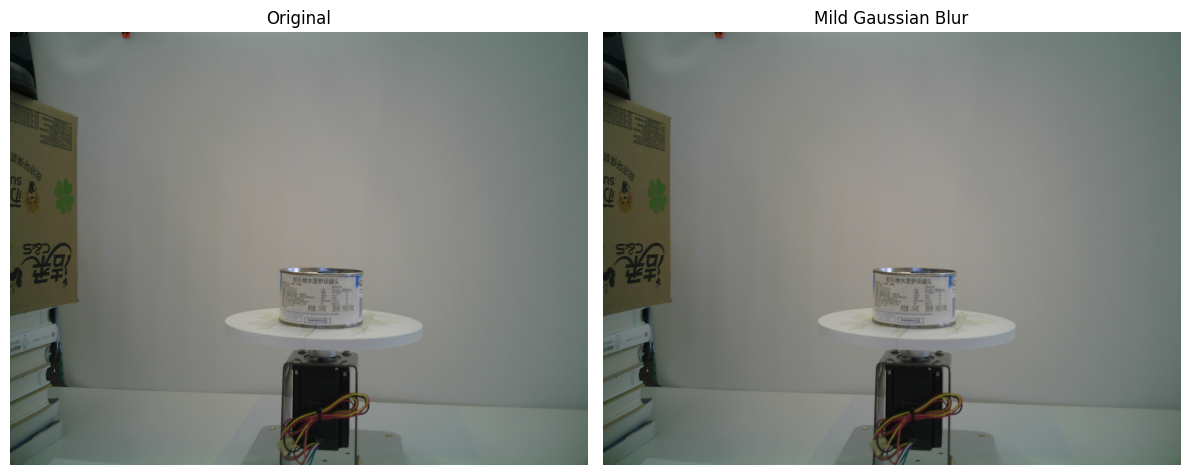

In [29]:
blurred = cv2.GaussianBlur(
    original,
    (3, 3),
    0
)

blurred_rgb = cv2.cvtColor(
    blurred,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_rgb)
plt.title("Mild Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

### Decision

The Gaussian blur operation is not required as a mandatory step in
the final pipeline because the RPC images are already suitable for
object detection and excessive smoothing could remove useful product
details.

It may be considered later only if validation experiments show a
measurable benefit.

## 15. Bounding Box Preservation Verification

The project uses bounding-box annotations to detect individual
products.

When an image is resized and padded, bounding boxes must undergo the
same geometric transformation.

This section verifies the transformation using one YOLO annotation.

YOLO annotation format:

class_id x_center y_center width height

All coordinates are normalized to [0, 1].

The transformation converts normalized YOLO coordinates to pixel
coordinates, applies the same scale and padding as the image, and
then converts the coordinates back to the new 640x640 image.

In [30]:
def read_yolo_labels(label_path):
    boxes = []

    if not label_path.exists():
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])
            xc, yc, w, h = map(float, values[1:])

            boxes.append({
                "class_id": class_id,
                "xc": xc,
                "yc": yc,
                "w": w,
                "h": h
            })

    return boxes

In [31]:
label_path = TRAIN_LABELS_DIR / f"{sample_path.stem}.txt"

boxes = read_yolo_labels(label_path)

print("Image:", sample_path.name)
print("Number of bounding boxes:", len(boxes))

for box in boxes[:5]:
    print(box)

Image: 038900004095_camera0-15.jpg
Number of bounding boxes: 1
{'class_id': 2, 'xc': 0.537793, 'yc': 0.611283, 'w': 0.151219, 'h': 0.147495}


Transform Bounding Boxes

In [32]:
def transform_yolo_box(
    box,
    original_width,
    original_height,
    scale,
    pad_x,
    pad_y,
    target_size=640
):
    """
    Transform a normalized YOLO bounding box after
    letterbox resizing and padding.
    """

    xc = box["xc"] * original_width
    yc = box["yc"] * original_height
    w = box["w"] * original_width
    h = box["h"] * original_height

    # Transform center
    new_xc = xc * scale + pad_x
    new_yc = yc * scale + pad_y

    # Transform width and height
    new_w = w * scale
    new_h = h * scale

    # Convert back to normalized coordinates
    new_xc /= target_size
    new_yc /= target_size
    new_w /= target_size
    new_h /= target_size

    return {
        "class_id": box["class_id"],
        "xc": new_xc,
        "yc": new_yc,
        "w": new_w,
        "h": new_h
    }

## 17. Visual Verification of Bounding Boxes

The transformed bounding boxes are drawn on the preprocessed image.

This provides visual evidence that the image transformation and
annotation transformation remain synchronized.

Correct synchronization is essential because incorrect bounding-box
coordinates would negatively affect YOLO training.

In [33]:
def draw_yolo_boxes(
    image,
    boxes,
    class_names,
    thickness=2
):
    output = image.copy()

    height, width = output.shape[:2]

    for box in boxes:

        class_id = box["class_id"]

        xc = box["xc"] * width
        yc = box["yc"] * height
        bw = box["w"] * width
        bh = box["h"] * height

        x1 = int(xc - bw / 2)
        y1 = int(yc - bh / 2)
        x2 = int(xc + bw / 2)
        y2 = int(yc + bh / 2)

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            thickness
        )

        label = class_names[class_id]

        cv2.putText(
            output,
            label,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    return output

In [34]:
def draw_yolo_boxes(
    image,
    boxes,
    class_names,
    thickness=2
):
    output = image.copy()

    height, width = output.shape[:2]

    for box in boxes:

        class_id = box["class_id"]

        xc = box["xc"] * width
        yc = box["yc"] * height
        bw = box["w"] * width
        bh = box["h"] * height

        x1 = int(xc - bw / 2)
        y1 = int(yc - bh / 2)
        x2 = int(xc + bw / 2)
        y2 = int(yc + bh / 2)

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            thickness
        )

        label = class_names[class_id]

        cv2.putText(
            output,
            label,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    return output

## 18. Automated Bounding Box Validation

All transformed bounding boxes are checked to ensure that their
normalized coordinates remain valid.

Valid YOLO coordinates must satisfy:

0 <= x_center <= 1
0 <= y_center <= 1
0 < width <= 1
0 < height <= 1

This check helps ensure that preprocessing does not generate
invalid training annotations.

In [36]:
print("========== AUTOMATED BOUNDING BOX VALIDATION ==========")

# Make sure the required variables exist
required_variables = [
    "boxes",
    "original",
    "scale",
    "pad_x",
    "pad_y",
    "TARGET_SIZE"
]

missing_variables = [
    var for var in required_variables
    if var not in globals()
]

if missing_variables:
    print("Missing variables:", missing_variables)
    print("\nPlease run the Bounding Box Transformation section first.")
else:

    # Recreate transformed boxes
    transformed_boxes = []

    for box in boxes:

        transformed_box = transform_yolo_box(
            box,
            original_width=original.shape[1],
            original_height=original.shape[0],
            scale=scale,
            pad_x=pad_x,
            pad_y=pad_y,
            target_size=TARGET_SIZE
        )

        transformed_boxes.append(transformed_box)

    # Validate transformed boxes
    invalid_boxes = validate_boxes(transformed_boxes)

    print("Total original boxes    :", len(boxes))
    print("Total transformed boxes :", len(transformed_boxes))
    print("Invalid transformed boxes:", len(invalid_boxes))

    if len(invalid_boxes) == 0:
        print("\nBOUNDING BOX TRANSFORMATION: PASS")
    else:
        print("\nBOUNDING BOX TRANSFORMATION: REVIEW REQUIRED")

        print("\nFirst invalid boxes:")
        for item in invalid_boxes[:10]:
            print(item)

========== AUTOMATED BOUNDING BOX VALIDATION ==========
Total original boxes    : 1
Total transformed boxes : 1
Invalid transformed boxes: 0

BOUNDING BOX TRANSFORMATION: PASS


## 19. Batch-Level Preprocessing Verification

A larger sample of images is processed to verify that the
preprocessing pipeline works consistently across the dataset.

The purpose is verification rather than permanently generating a
second copy of the entire dataset.

This avoids unnecessary disk usage and keeps the project efficient.

In [37]:
def verify_preprocessing_batch(image_dir, sample_count=100):

    image_files = sorted(image_dir.glob("*.jpg"))[:sample_count]

    results = []

    for path in image_files:

        image = cv2.imread(str(path))

        if image is None:
            results.append({
                "filename": path.name,
                "loaded": False,
                "output_shape": None
            })
            continue

        processed, scale, pad_x, pad_y = letterbox_image(
            image,
            target_size=TARGET_SIZE
        )

        results.append({
            "filename": path.name,
            "loaded": True,
            "original_height": image.shape[0],
            "original_width": image.shape[1],
            "output_height": processed.shape[0],
            "output_width": processed.shape[1],
            "scale": scale,
            "pad_x": pad_x,
            "pad_y": pad_y
        })

    return pd.DataFrame(results)

In [38]:
preprocessing_results = verify_preprocessing_batch(
    TRAIN_IMAGES_DIR,
    sample_count=100
)

display(preprocessing_results.head())

,filename,loaded,original_height,original_width,output_height,output_width,scale,pad_x,pad_y
0,038900004095_camera0-15.jpg,True,1944,2592,640,640,0.246914,0,80
1,038900004095_camera0-17.jpg,True,1944,2592,640,640,0.246914,0,80
2,038900004095_camera0-29.jpg,True,1944,2592,640,640,0.246914,0,80
3,038900004095_camera0-37.jpg,True,1944,2592,640,640,0.246914,0,80
4,038900004095_camera1-11.jpg,True,1944,2592,640,640,0.246914,0,80


In [39]:
print("========== BATCH PREPROCESSING CHECK ==========")

print("Images checked:",
      len(preprocessing_results))

print("Images successfully loaded:",
      preprocessing_results["loaded"].sum())

print("Incorrect output sizes:",
      (
          (preprocessing_results["output_height"] != 640) |
          (preprocessing_results["output_width"] != 640)
      ).sum())

========== BATCH PREPROCESSING CHECK ==========
Images checked: 100
Images successfully loaded: 100
Incorrect output sizes: 0


## 20. Preprocessing Efficiency

The preprocessing time is measured on a sample of images.

Efficient preprocessing is important because the final system should
be able to process supermarket images without unnecessary delays.

Only the required operations are performed, and the complete
dataset is not duplicated unnecessarily.

In [40]:
import time

benchmark_files = sorted(
    TRAIN_IMAGES_DIR.glob("*.jpg")
)[:100]

start_time = time.perf_counter()

processed_count = 0

for path in benchmark_files:

    image = cv2.imread(str(path))

    if image is None:
        continue

    processed, _, _, _ = letterbox_image(
        image,
        target_size=TARGET_SIZE
    )

    processed_count += 1

elapsed = time.perf_counter() - start_time

print("========== PREPROCESSING BENCHMARK ==========")
print("Images processed:", processed_count)
print(f"Total time      : {elapsed:.4f} seconds")

if processed_count > 0:
    print(
        f"Average/image   : "
        f"{elapsed / processed_count:.6f} seconds"
    )

    print(
        f"Images/second   : "
        f"{processed_count / elapsed:.2f}"
    )

========== PREPROCESSING BENCHMARK ==========
Images processed: 100
Total time      : 2.8009 seconds
Average/image   : 0.028009 seconds
Images/second   : 35.70


## 21. Final Preprocessing Pipeline

Based on the preprocessing experiments and the requirements of
retail product detection, the following pipeline is selected:

### Final Pipeline

1. Load colour image using OpenCV
2. Preserve three-channel colour information
3. Resize while preserving aspect ratio
4. Pad to 640 × 640
5. Normalize pixel values when required for model input
6. Pass the processed image to the YOLO26s detection model

### Not included as mandatory preprocessing

- Grayscale conversion
- Edge detection
- Heavy Gaussian blur
- Aggressive sharpening

These operations are excluded because they may remove useful
product appearance information.

### Important

The final YOLO training pipeline will use the model's supported
image preprocessing and augmentation mechanisms where appropriate.
The OpenCV implementation in this notebook demonstrates the image
processing principles and verifies that the project dataset can be
prepared safely for detection.

In [41]:
print("=" * 60)
print("PHASE 3 - IMAGE PREPROCESSING SUMMARY")
print("=" * 60)

print("\nDataset")
print("Train images      :", count_files(TRAIN_IMAGES_DIR, "*.jpg"))
print("Validation images :", count_files(VAL_IMAGES_DIR, "*.jpg"))
print("Test images       :", count_files(TEST_IMAGES_DIR, "*.jpg"))

print("\nPreprocessing")
print("Target image size :", f"{TARGET_SIZE} x {TARGET_SIZE}")
print("Colour channels   : 3")
print("Aspect ratio      : Preserved")
print("Padding           : Yes")
print("Normalization     : Supported")

print("\nBounding Boxes")
print("Transformation verified :", len(invalid_boxes) == 0)
print("Invalid boxes            :", len(invalid_boxes))

print("\nBatch Verification")
print("Images checked           :", len(preprocessing_results))
print(
    "Successfully processed   :",
    preprocessing_results["loaded"].sum()
)

print("\n" + "=" * 60)

PHASE 3 - IMAGE PREPROCESSING SUMMARY

Dataset
Train images      : 5000
Validation images : 1000
Test images       : 1000

Preprocessing
Target image size : 640 x 640
Colour channels   : 3
Aspect ratio      : Preserved
Padding           : Yes
Normalization     : Supported

Bounding Boxes
Transformation verified : True
Invalid boxes            : 0

Batch Verification
Images checked           : 100
Successfully processed   : 100



# 22. Phase 3 Conclusion

The image preprocessing stage was implemented and verified using
OpenCV and NumPy.

The preprocessing pipeline preserves the colour and visual
characteristics of supermarket products while providing a
consistent 640 × 640 representation for object detection.

The following tasks were completed:

- Verified the prepared dataset structure
- Analyzed image dimensions
- Loaded and inspected representative RPC images
- Implemented aspect-ratio-preserving resizing
- Implemented padding to 640 × 640
- Implemented pixel normalization
- Evaluated grayscale conversion experimentally
- Evaluated mild noise reduction experimentally
- Preserved colour information for the final pipeline
- Transformed bounding boxes consistently with image resizing
- Validated transformed bounding-box coordinates
- Performed batch-level preprocessing verification
- Measured preprocessing efficiency

### Final Decision

The final preprocessing strategy retains RGB colour information,
preserves aspect ratio, uses 640 × 640 padded images, and avoids
unnecessary image transformations that could remove useful product
features.

The dataset is now ready for the model training stage.

### Next Phase

Phase 4 — YOLO26s Model Training